<a href="https://colab.research.google.com/github/jnahMoch/revisedBookRecommender/blob/main/vector_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install langchain langchain-community langchain-openai langchain-chroma chromadb pandas python-dotenv sentence-transformers


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Boo Family\OneDrive - umindanao.edu.ph\Documents\Final Project\BookRecommender\revisedBookRecommender\.venv\Scripts\python.exe -m pip install --upgrade pip


In [ ]:
import os

import pandas as pd

try:

    from google.colab import userdata

    colab = True

except Exception:

    userdata = None

    colab = False



# Use local Sentence-Transformers for embeddings (no OpenAI key required)

from sentence_transformers import SentenceTransformer

from langchain_chroma import Chroma

from langchain_community.document_loaders import TextLoader

from langchain_text_splitters import RecursiveCharacterTextSplitter



class LocalEmbeddings:

    def __init__(self, model_name='all-MiniLM-L6-v2'):

        self.model = SentenceTransformer(model_name)

    def embed_documents(self, texts):

        return self.model.encode(texts, show_progress_bar=False).tolist()

    def embed_query(self, text):

        return self.model.encode([text], show_progress_bar=False).tolist()[0]



# ===================================================

# 1. SAFELY FETCH YOUR API KEY FROM COLAB SECRETS OR ENV (optional)

# ===================================================

from dotenv import load_dotenv

load_dotenv()

if colab:

    MY_API_KEY = userdata.get('OPENAI_API_KEY', '').strip()

else:

    MY_API_KEY = os.getenv('OPENAI_API_KEY', '').strip()



if not MY_API_KEY:

    print("⚠️ OPENAI_API_KEY not found — continuing with local sentence-transformers embeddings.")

else:

    os.environ["OPENAI_API_KEY"] = MY_API_KEY

    print("✅ Loaded OpenAI API Key from Colab Secrets." if colab else "✅ Loaded OpenAI API Key from OPENAI_API_KEY environment variable.")


C:\Users\Boo Family\OneDrive - umindanao.edu.ph\Documents\Final Project\BookRecommender\revisedBookRecommender\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\Boo Family\AppData\Local\Temp\ipykernel_3912\2341172714.py:25: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


⚠️ OPENAI_API_KEY not found — continuing with local sentence-transformers embeddings.


In [3]:
# ===================================================
# 2. LOAD & CLEAN DATASET
# ===================================================
print("🔄 Loading and cleaning dataset...")
books = pd.read_csv("books_with_categories_and_genre.csv")

# Fill missing items so string combining doesn't crash
books['title'] = books['title'].fillna('')
books['genre'] = books['genre'].fillna('')
books['simple_categories_binary'] = books['simple_categories_binary'].fillna('')
books['description'] = books['description'].fillna('')

# Build the custom tagged description where ISBN13 is always the FIRST word
books["tagged_description"] = (
    books["isbn13"].astype(str) + " " +
    books["title"] + " " +
    books["genre"] + " " +
    books["simple_categories_binary"] + " " +
    books["description"]
)

# Strip out empty strings
books = books[books["tagged_description"].str.strip() != ""]

# Save out to flat text loader file
books["tagged_description"].to_csv("tagged_description.txt", sep="\t", index=False, header=False)
print("   -> Created 'tagged_description.txt' successfully.")


🔄 Loading and cleaning dataset...
   -> Created 'tagged_description.txt' successfully.


In [ ]:
# ===================================================
# 3. PARSE DOCUMENTS LINE-BY-LINE
# ===================================================
raw_documents = TextLoader("tagged_description.txt", encoding="utf-8").load()
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", " ", ""],
    strip_whitespace=True,
)
documents = text_splitter.split_documents(raw_documents)
print(f"   -> Split texts into {len(documents)} distinct book blocks.")

Created a chunk of size 1202, which is longer than the specified 500


Created a chunk of size 1254, which is longer than the specified 500


Created a chunk of size 536, which is longer than the specified 500


Created a chunk of size 536, which is longer than the specified 500


Created a chunk of size 1008, which is longer than the specified 500


...

Created a chunk of size 660, which is longer than the specified 500


Created a chunk of size 764, which is longer than the specified 500


Created a chunk of size 1204, which is longer than the specified 500


Created a chunk of size 922, which is longer than the specified 500


   -> Split texts into 908 distinct book blocks.


In [5]:
# ===================================================

# 4. INITIALIZE CHROMA WITH LOCAL EMBEDDINGS

# ===================================================

print("Initialized Vector Database (using local sentence-transformers embeddings)")



embedding_model = LocalEmbeddings('all-MiniLM-L6-v2')



db_books = Chroma.from_documents(

    documents,

    embedding=embedding_model

)


Initialized Vector Database (using local sentence-transformers embeddings)



Loading weights:   0%|                                 | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|█████████████████████| 103/103 [00:00<00:00, 3507.65it/s]

In [6]:
# ===================================================
# 5. CRASH-PROOF RECOMMENDATION FUNCTION
# ===================================================
def retrieve_semantic_recommendations(query: str, top_k: int = 10) -> pd.DataFrame:
    recs = db_books.similarity_search(query, k=50)
    books_list = []

    for i in range(len(recs)):
        try:
            content = recs[i].page_content.strip('"').strip()
            if not content:
                continue

            words = content.split()
            if len(words) > 0:
                raw_isbn = words[0].strip()
                # Clean datatype parsing to match integers
                clean_isbn = int(float(raw_isbn))
                books_list.append(clean_isbn)
        except (ValueError, IndexError):
            continue

    # Return matching results safely
    matched_books = books[books["isbn13"].isin(books_list)]
    return matched_books.head(top_k)

In [7]:
# ===================================================
# 6. RUN A TEST QUERY AUTOMATICALLY
# ===================================================
print("\n--- SAMPLE SEARCH RESULTS ---")
results = retrieve_semantic_recommendations("A suspenseful fiction murder mystery book", top_k=5)
display(results[['title','authors', 'genre', 'simple_categories_binary', 'average_rating']])



--- SAMPLE SEARCH RESULTS ---


,title,authors,genre,simple_categories_binary,average_rating
1,Spider's Web,Charles Osborne;Agatha Christie,Literature & Drama,fiction,3.83
13,Murder in LaMut,Raymond E. Feist;Joel Rosenberg,Literature & Drama,fiction,3.70
25,Murder in Mesopotamia,Agatha Christie,Literature & Drama,fiction,3.89
29,Hallowe'en Party,Agatha Christie,Literature & Drama,fiction,3.66
32,The Thirteen Problems,Agatha Christie,Literature & Drama,fiction,3.89


In [8]:
books.head()

,isbn13,isbn10,title,authors,categories,description,thumbnail,average_rating,num_pages,cleaned_description,simple_categories_binary,genre,tagged_description
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,A NOVEL THAT READERS and critics have been eag...,http://books.google.com/books/content?id=KQZCP...,3.85,247.0,novel reader critic eagerly anticipating decad...,fiction,Literature & Drama,9780002005883 Gilead Literature & Drama fictio...
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Fiction,A new 'Christie for Christmas' -- a full-lengt...,http://books.google.com/books/content?id=gA5GP...,3.83,241.0,new christie christmas fulllength novel adapte...,fiction,Literature & Drama,9780002261982 Spider's Web Literature & Drama ...
2,9780006163831,0006163831,The One Tree,Stephen R. Donaldson,Fiction,Volume Two of Stephen Donaldson's acclaimed se...,http://books.google.com/books/content?id=OmQaw...,3.97,479.0,volume two stephen donaldsons acclaimed second...,fiction,Literature & Drama,9780006163831 The One Tree Literature & Drama ...
3,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,"A memorable, mesmerizing heroine Jennifer -- b...",http://books.google.com/books/content?id=FKo2T...,3.93,512.0,memorable mesmerizing heroine jennifer brillia...,fiction,Literature & Drama,9780006178736 Rage of angels Literature & Dram...
4,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Religion,Lewis' work on the nature of love divides love...,http://books.google.com/books/content?id=XhQ5X...,4.15,170.0,lewis work nature love divide love four catego...,nonfiction,Philosophy & Religion,9780006280897 The Four Loves Philosophy & Reli...


In [9]:
#Test here:



search_query = "A suspenseful fiction murder mystery book"

try:

    user_input = input("Type here: ")

    if user_input and user_input.strip():

        search_query = user_input.strip()

except Exception:

    print("Input not available in this execution environment; using default query.")



print(f"Running query: {search_query}")

results = retrieve_semantic_recommendations(search_query, top_k=5)

display(results[['title','authors', 'genre', 'simple_categories_binary', 'average_rating', 'description']])


Input not available in this execution environment; using default query.
Running query: A suspenseful fiction murder mystery book


,title,authors,genre,simple_categories_binary,average_rating,description
1,Spider's Web,Charles Osborne;Agatha Christie,Literature & Drama,fiction,3.83,A new 'Christie for Christmas' -- a full-lengt...
13,Murder in LaMut,Raymond E. Feist;Joel Rosenberg,Literature & Drama,fiction,3.70,"Available in the U.S. for the first time, this..."
25,Murder in Mesopotamia,Agatha Christie,Literature & Drama,fiction,3.89,An archaeologist's wife is murdered on the sho...
29,Hallowe'en Party,Agatha Christie,Literature & Drama,fiction,3.66,No one believes a little girl when she insists...
32,The Thirteen Problems,Agatha Christie,Literature & Drama,fiction,3.89,The Tuesday Night Club is a venue where locals...


In [10]:
# Evaluation

evaluation_benchmarks = {
    "A story about a priest or preacher in a small town": [9780002005883], # Gilead
    "Agatha Christie style mystery play novelisation": [9780002261982],    # Spider's Web
    "Stephen Donaldson epic fantasy anti-hero trilogy": [9780006163831]   # The One Tree
}

def evaluate_vector_search(benchmarks, k=5):
    total_queries = len(benchmarks)
    hits = 0
    precision_scores = []

    print(f" Evaluating Vector Engine (Top K={k})")

    for query, true_isbns in benchmarks.items():
        results_df = retrieve_semantic_recommendations(query, top_k=k)
        predicted_isbns = results_df["isbn13"].tolist()

        has_hit = any(isbn in predicted_isbns for isbn in true_isbns)
        if has_hit:
            hits += 1

        matched_count = sum(1 for isbn in predicted_isbns if isbn in true_isbns)
        precision_scores.append(matched_count / k)

        print(f"Query: '{query}' -> {'✅ HIT' if has_hit else '❌ MISS'} (Precision: {matched_count/k:.2f})")

    print("FINAL IR PERFORMANCE METRICS")
    print(f"System Hit-Rate@{k}: {hits / total_queries:.2%}")
    print(f"Average Precision@{k}: {sum(precision_scores) / total_queries:.2%}")

In [11]:
evaluate_vector_search(evaluation_benchmarks, k=5)

 Evaluating Vector Engine (Top K=5)
Query: 'A story about a priest or preacher in a small town' -> ✅ HIT (Precision: 0.20)
Query: 'Agatha Christie style mystery play novelisation' -> ✅ HIT (Precision: 0.20)
Query: 'Stephen Donaldson epic fantasy anti-hero trilogy' -> ✅ HIT (Precision: 0.20)
FINAL IR PERFORMANCE METRICS
System Hit-Rate@5: 100.00%
Average Precision@5: 20.00%


Metadata Alignment Audit for Query: 'Historical politics and biographical war documents'

 Discovered Genre Distribution:
genre
Biography & History      80.0%
Literature & Drama       15.0%
Academic & Humanities     5.0%
Name: proportion, dtype: str

 Discovered Binary Distribution:
simple_categories_binary
nonfiction    85.0%
fiction       15.0%
Name: proportion, dtype: str


C:\Users\Boo Family\AppData\Local\Temp\ipykernel_3912\4147644286.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=results, x='genre', palette="Set3", order=results['genre'].value_counts().index)


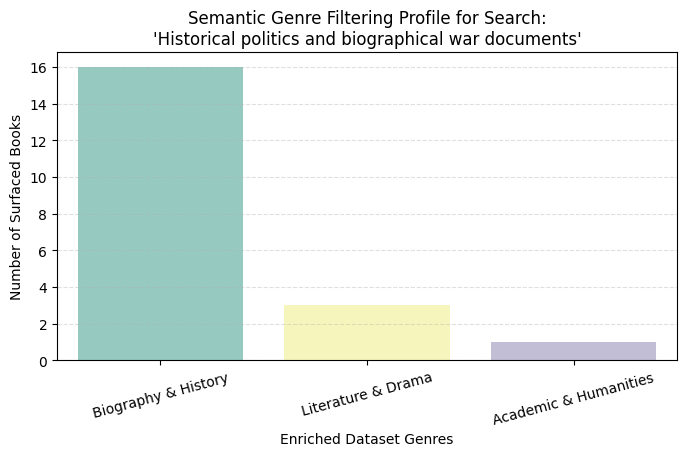

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def audit_semantic_alignment(query, test_k=25):
    results = retrieve_semantic_recommendations(query, top_k=test_k)

    print(f"Metadata Alignment Audit for Query: '{query}'")
    print("\n Discovered Genre Distribution:")
    print(results['genre'].value_counts(normalize=True).map(lambda n: f"{n:.1%}"))

    print("\n Discovered Binary Distribution:")
    print(results['simple_categories_binary'].value_counts(normalize=True).map(lambda n: f"{n:.1%}"))

    plt.figure(figsize=(8, 4))
    sns.countplot(data=results, x='genre', palette="Set3", order=results['genre'].value_counts().index)
    plt.title(f"Semantic Genre Filtering Profile for Search:\n'{query}'")
    plt.ylabel("Number of Surfaced Books")
    plt.xlabel("Enriched Dataset Genres")
    plt.xticks(rotation=15)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()

audit_semantic_alignment("Historical politics and biographical war documents", test_k=20)